In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
from models.linear_probes import linear_probe, linear_probe_tuned,linear_probe_tuned_smote
from models.feature_generation import build_feature_bank, extract_encoder, extract_feature,pool_features
from preprocessing.dataset import PipistrelleDataset
from evaluation.metrics import compute_cv_stats,plot_model_comparison,label_confusion
import pandas as pd
from sklearn.metrics import average_precision_score
from evaluation.metrics import compute_metrics,compile_results,generate_metrics_table2
from evaluation.metrics import plot_comprehensive_calibration,plot_loss_curves,plot_comprehensive_results3
from models.MLP_balancing import balancing_mlp,balancing_mlp_val,data_augmented_mlp
import pickle
from pathlib import Path
import os
from models.mlsmote import get_minority_instace,MLSMOTE
from tabulate import tabulate

c:\Users\artem\AppData\Local\miniconda3\envs\playground\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
c:\Users\artem\AppData\Local\miniconda3\envs\playground\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)
c:\Users\artem\AppData\Local\m

In [9]:
dir = Path(os.getcwd()).resolve().parent / "data"
data_augment_results = data_augmented_mlp(csv_data=str(dir / "bat_metadata.csv"),
                             root_dir=str(dir / "xenocanto-dataset"),num_trials=1)

Starting Trial 1/1 with random_state=42...
  Tuning and evaluating model: MLP_Baseline
    Evaluating fold 1/5
Final counts: [ 29  66 128  29 189]
Dataset type: <class 'preprocessing.dataset.PipistrelleDataset'>


Extracting perch2: 100%|██████████| 244/244 [25:06<00:00,  6.18s/it]


Train features extracted
Dataset type: <class 'preprocessing.dataset.PipistrelleDataset'>


Extracting perch2: 100%|██████████| 56/56 [05:48<00:00,  6.22s/it]


Test features extracted
Model trained
    Evaluating fold 2/5
Final counts: [ 29  63 133  30 192]
Dataset type: <class 'preprocessing.dataset.PipistrelleDataset'>


...

Test features extracted
Model trained
    Evaluating fold 5/5
Final counts: [ 29  63 130  29 189]
Dataset type: <class 'preprocessing.dataset.PipistrelleDataset'>


Extracting perch2: 100%|██████████| 245/245 [24:33<00:00,  6.02s/it]


Train features extracted
Dataset type: <class 'preprocessing.dataset.PipistrelleDataset'>


Extracting perch2: 100%|██████████| 55/55 [04:45<00:00,  5.19s/it]


Test features extracted
Model trained


In [10]:
label_names = ['Type A', 'Type B', 'Type C', 'Type D','Echo']

per2_compiled_augmented = compile_results(data_augment_results,label_names=label_names,encoder="per2")

df = pd.DataFrame(generate_metrics_table2(per2_compiled_augmented,label_names=label_names)[0])
print(tabulate(df, headers='keys', tablefmt='psql'))

+----+-------------------+---------------+-------------------+-----------------+---------------+
|    | Model             | Macro-AUC     | Macro-AP (cmAP)   | Brier Score ↓   | Log-Loss ↓    |
|----+-------------------+---------------+-------------------+-----------------+---------------|
|  0 | per2 MLP_Baseline | 0.939 ± 0.000 | 0.862 ± 0.000     | 0.059 ± 0.000   | 0.384 ± 0.000 |
+----+-------------------+---------------+-------------------+-----------------+---------------+


In [11]:
df2 = pd.DataFrame(generate_metrics_table2(per2_compiled_augmented,label_names=label_names)[1])
print(tabulate(df2, headers='keys', tablefmt='psql'))

+----+-------------------+---------------+---------------+---------------+---------------+---------------+
|    | Model             | Type A AP     | Type B AP     | Type C AP     | Type D AP     | Echo AP       |
|----+-------------------+---------------+---------------+---------------+---------------+---------------|
|  0 | per2 MLP_Baseline | 0.531 ± 0.000 | 0.927 ± 0.000 | 0.927 ± 0.000 | 0.960 ± 0.000 | 0.963 ± 0.000 |
+----+-------------------+---------------+---------------+---------------+---------------+---------------+


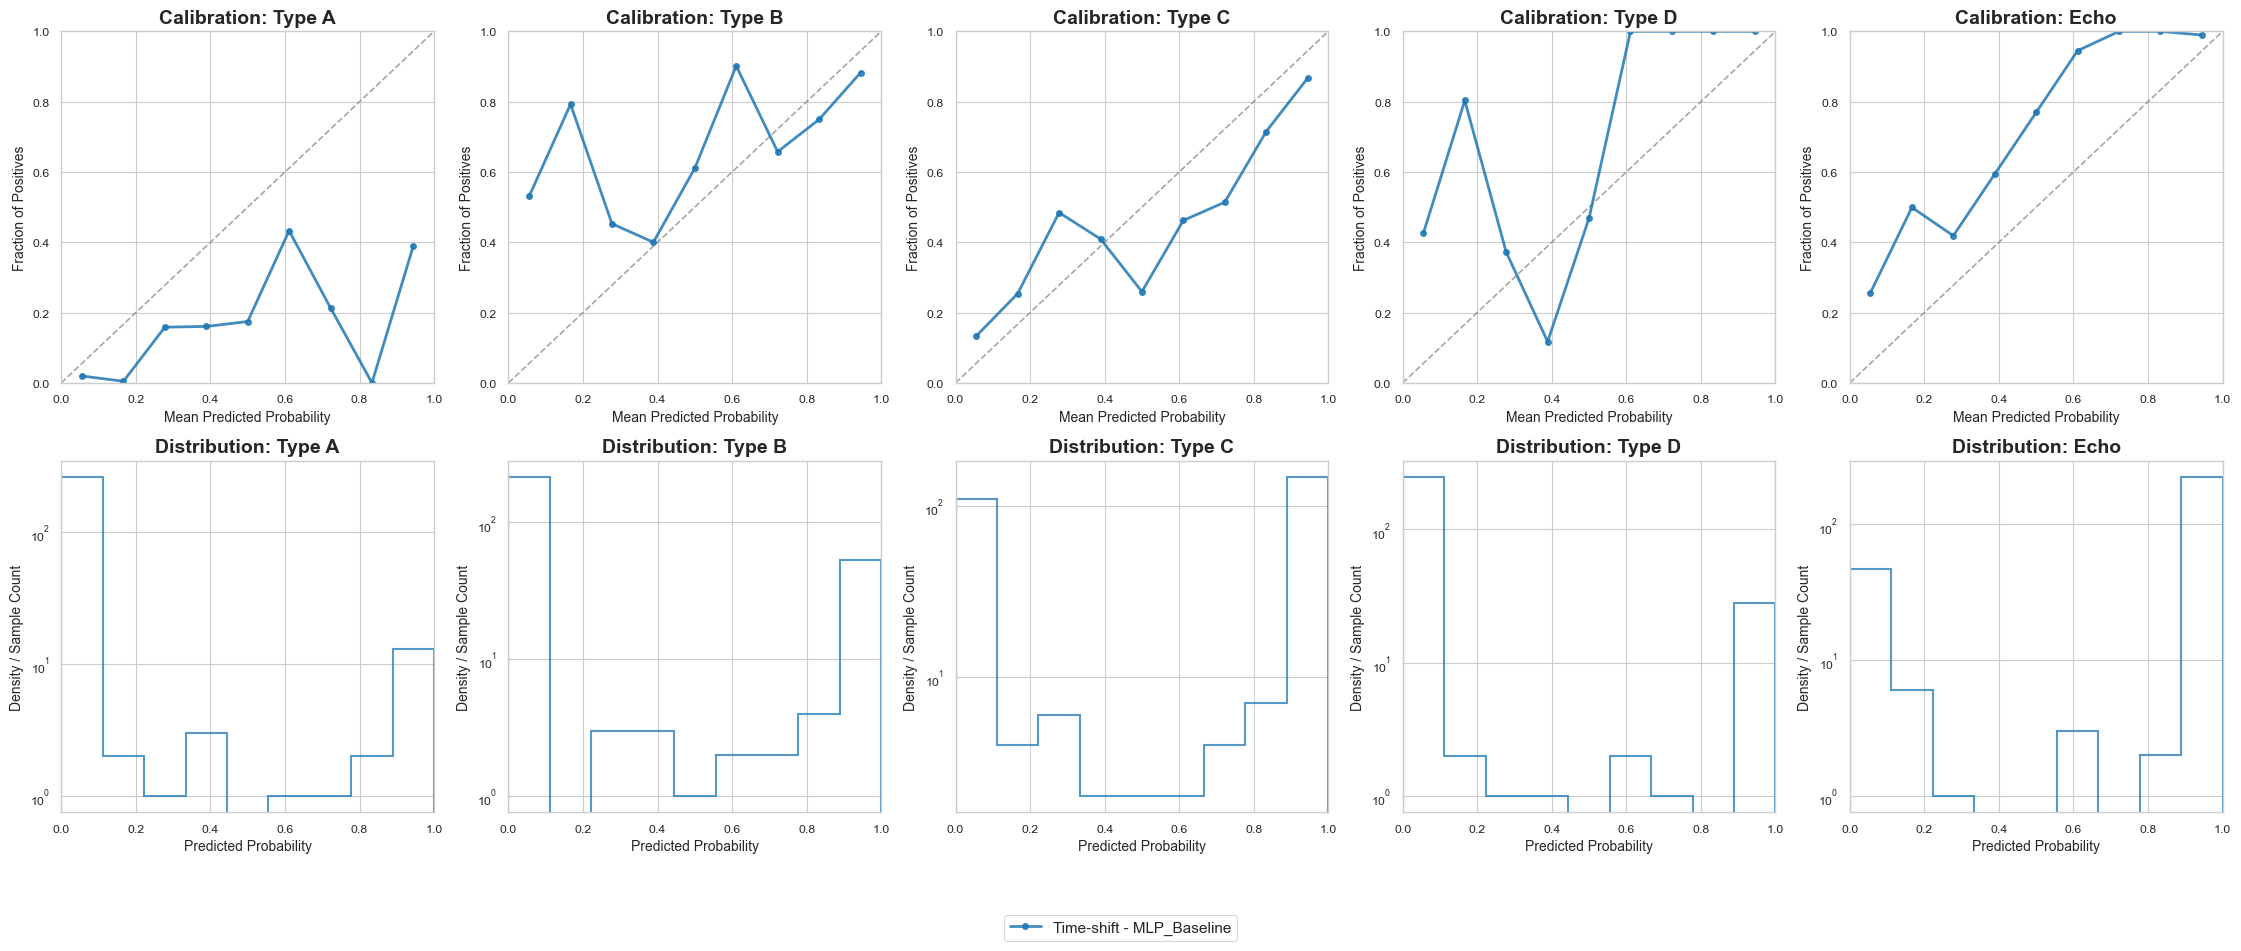

In [12]:
my_pipeline_results = {
    "Time-shift": data_augment_results,                     # Your actual trial dictionary list
}

target_labels =  ['Type A', 'Type B', 'Type C', 'Type D','Echo']

# 2. Render your visual evaluation assets
plot_comprehensive_calibration(
    encoder_results=my_pipeline_results, 
    label_names=target_labels, 
    n_bins=10, 
    strategy="uniform"
)

In [ ]:
from preprocessing.dataset import BatAudioPipeline
file_path = r"C:\Users\artem\Nast. Code\new-git\bat-social-call-classifier\data\xenocanto-dataset\Echolocation\Pipistrellus_pipistrellus_DIG0112_11.wav"
a = BatAudioPipeline().forward(file_path,timeshift=True)
print(a.shape)

In [ ]:
import matplotlib.pyplot as plt
import librosa
from preprocessing.dataset import BatAudioPipeline
file_path = r"C:\Users\artem\Nast. Code\new-git\bat-social-call-classifier\data\xenocanto-dataset\type C\XC911624 - Common Pipistrelle - Pipistrellus pipistrellus.wav"
a = BatAudioPipeline().forward(file_path,timeshift=True)
print(a.shape)
first_window = a[10]

fig, axes = plt.subplots(2, 1, figsize=(12, 15))

data_win = first_window.detach().cpu().numpy().flatten()
stft_result = librosa.stft(data_win)
D_win = librosa.amplitude_to_db(np.abs(stft_result), ref=np.max)
img3 = librosa.display.specshow(D_win, sr=32000, x_axis='time', y_axis='linear', ax=axes[0])
axes[0].set_title(f"3. Single 10s Window (Sent to Encoder)")
fig.colorbar(img3, ax=axes[0], format="%+2.0f dB")
plt.tight_layout()
plt.show()